# Federated Learning for Privacy-Preserving Healthcare AI

---

### Problem Statement
Hospitals cannot share patient data due to **HIPAA** (US) and **GDPR** (EU) privacy laws.
This notebook trains a diabetes-risk model **across 5 hospitals without ever sharing raw patient records**.

### Architecture
```
Hospital 1 ----|
Hospital 2 ----|
Hospital 3 ----|-----> Aggregation Server (FedAvg) -----> Global Model
Hospital 4 ----|         weights only, never data
Hospital 5 ----|
```

### Privacy Guarantees
| Regulation | Article | How We Comply |
|---|---|---|
| HIPAA | 164.312 | No PHI transmitted - only model weights |
| GDPR | Art. 25 | Privacy by Design - data minimisation |
| GDPR | Art. 35 | Audit log produced per aggregation round |

### Algorithm: FedAvg (McMahan et al., 2017)
Each round: (1) Server broadcasts global weights to hospitals,
(2) each hospital runs local SGD on its own data,
(3) server aggregates: **w = sum((n_k/N) * w_k)**,
(4) repeat for T rounds.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
import warnings, json
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#3B8BD4', '#1D9E75', '#E8593C', '#BA7517', '#7F77DD']
print('All imports successful')

All imports successful


## 2. Upload Dataset

Upload `federated_health_dataset.csv` when prompted.

In [2]:
from google.colab import files
print('Please upload federated_health_dataset.csv ...')
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f'Loaded: {CSV_PATH}')

# Option B: Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# CSV_PATH = '/content/drive/MyDrive/federated_health_dataset.csv'

Please upload federated_health_dataset.csv ...


Saving federated_health_dataset.csv to federated_health_dataset.csv
Loaded: federated_health_dataset.csv


## 3. Exploratory Data Analysis

In [3]:
df_raw = pd.read_csv(CSV_PATH)
print('Dataset shape :', df_raw.shape)
print('Hospital nodes:', sorted(df_raw['client_id'].unique().tolist()))
print('Records/node  :', df_raw['client_id'].value_counts().to_dict())
display(df_raw.head(5))
display(df_raw.describe().round(2))

Dataset shape : (1000, 10)
Hospital nodes: ['client_1', 'client_2', 'client_3', 'client_4', 'client_5']
Records/node  : {'client_1': 200, 'client_2': 200, 'client_3': 200, 'client_4': 200, 'client_5': 200}


,client_id,age,bmi,blood_pressure,cholesterol_level,glucose_level,insulin_level,physical_activity_score,diet_quality_score,risk_of_diabetes
0,client_1,58,33.114602,126.694340,223.581019,148.596955,114.456870,5.536434,1.097763,0
1,client_1,71,29.118665,137.043635,191.385797,138.994652,97.089644,3.572767,3.742142,0
2,client_1,48,26.465296,127.521401,188.760160,88.724671,76.673548,3.252099,3.350063,0
3,client_1,34,29.483152,135.909579,175.439690,28.635894,108.141970,1.747565,5.322880,0
4,client_1,62,21.948390,109.965378,181.242854,92.869358,42.654259,8.433531,5.220981,0


,age,bmi,blood_pressure,cholesterol_level,glucose_level,insulin_level,physical_activity_score,diet_quality_score,risk_of_diabetes
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.0
mean,49.80,25.03,120.02,201.52,99.64,82.09,5.04,5.01,0.0
std,17.58,4.93,15.60,30.74,19.85,25.92,2.10,1.95,0.0
min,20.00,10.58,67.83,102.37,28.64,-3.69,0.00,0.00,0.0
25%,35.00,21.62,109.41,180.88,86.86,64.56,3.72,3.65,0.0
50%,50.00,24.80,119.75,202.79,99.95,80.82,5.05,5.02,0.0
75%,65.00,28.48,130.20,221.84,113.23,99.63,6.46,6.41,0.0
max,79.00,41.13,180.79,295.23,158.47,161.51,10.00,10.00,0.0


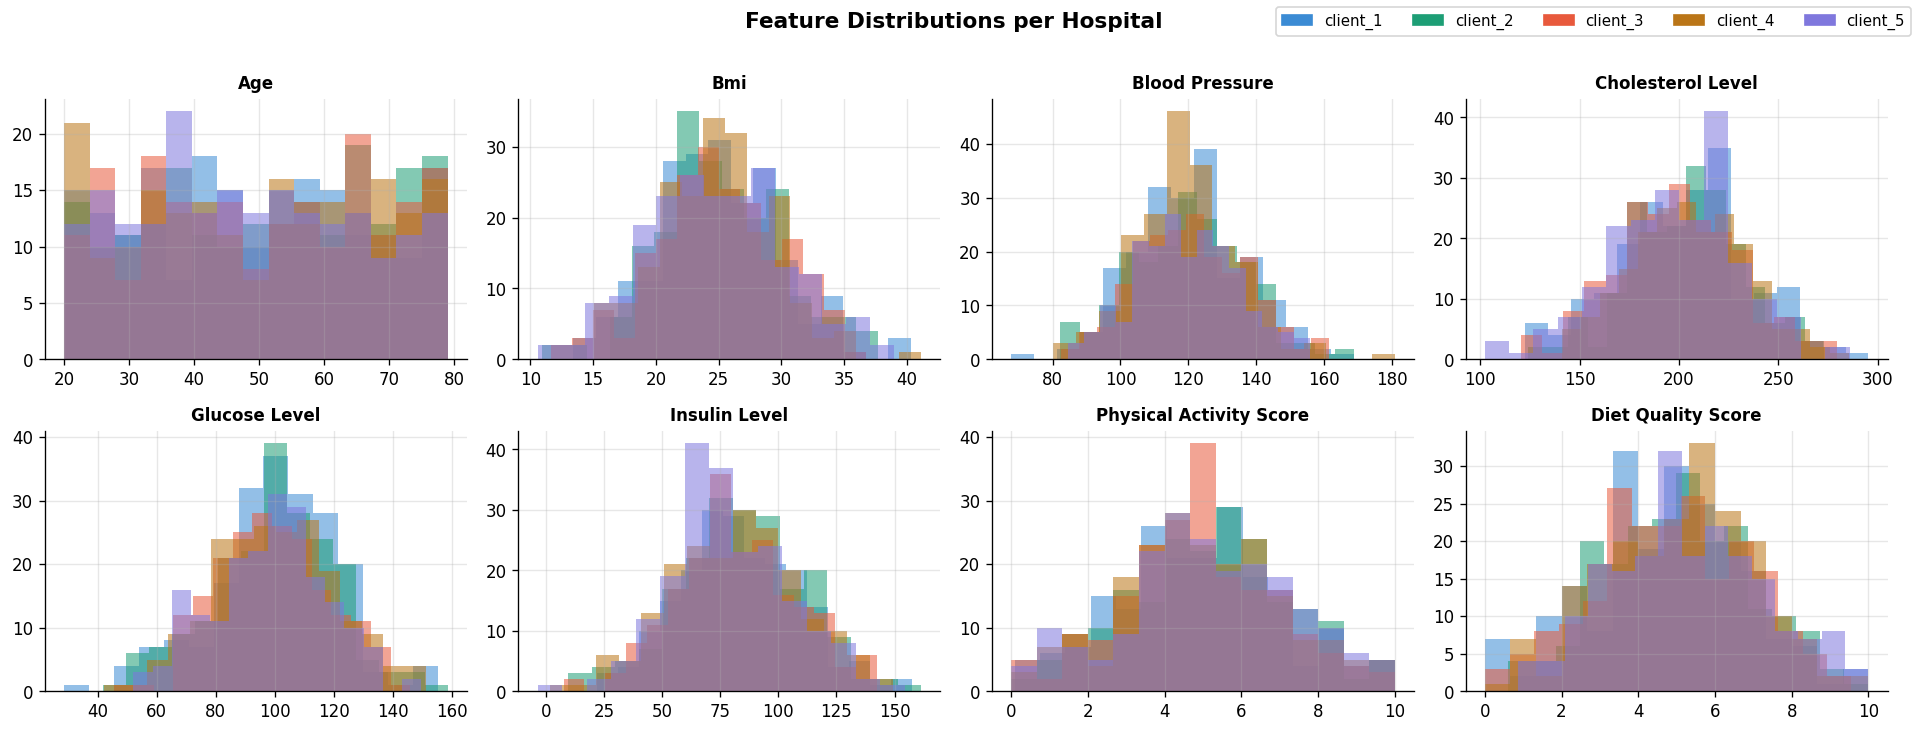

In [4]:
FEATURES = ['age', 'bmi', 'blood_pressure', 'cholesterol_level',
            'glucose_level', 'insulin_level', 'physical_activity_score', 'diet_quality_score']

clients = sorted(df_raw['client_id'].unique())
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    for j, cid in enumerate(clients):
        axes[i].hist(df_raw[df_raw['client_id']==cid][feat], bins=15,
                     alpha=0.55, color=PALETTE[j], label=cid)
    axes[i].set_title(feat.replace('_',' ').title(), fontsize=10, fontweight='bold')
handles = [mpatches.Patch(color=PALETTE[j], label=c) for j,c in enumerate(clients)]
fig.legend(handles=handles, loc='upper right', ncol=5, fontsize=9)
fig.suptitle('Feature Distributions per Hospital', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

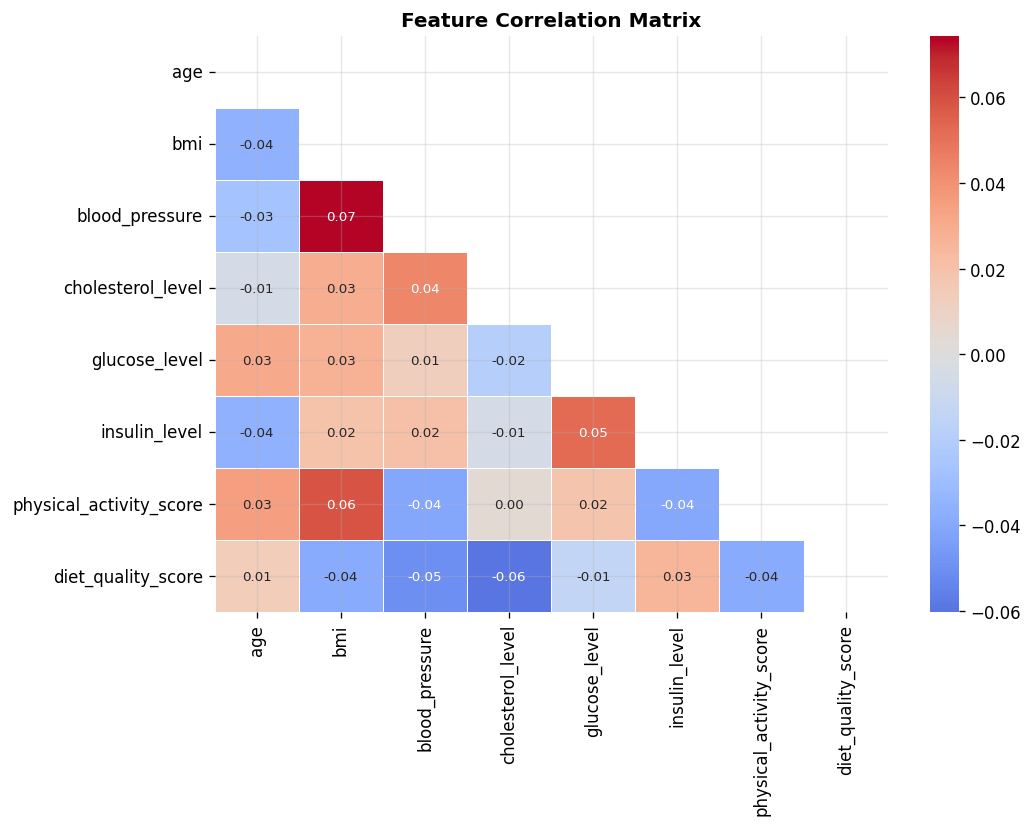

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df_raw[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Generate Clinically-Motivated Labels

> **Note:** The CSV `risk_of_diabetes` column is all zeros (placeholder).  
> We derive realistic binary labels locally at each hospital using clinical thresholds.

| Factor | Threshold | Weight |
|---|---|---|
| Glucose level | > 120 mg/dL | x3 |
| BMI | > 30 | x2 |
| Blood pressure | > 130 mmHg | x2 |
| Age | > 50 years | x1 |
| Cholesterol | > 200 mg/dL | x1 |
| Physical activity | score < 3 | x1 |

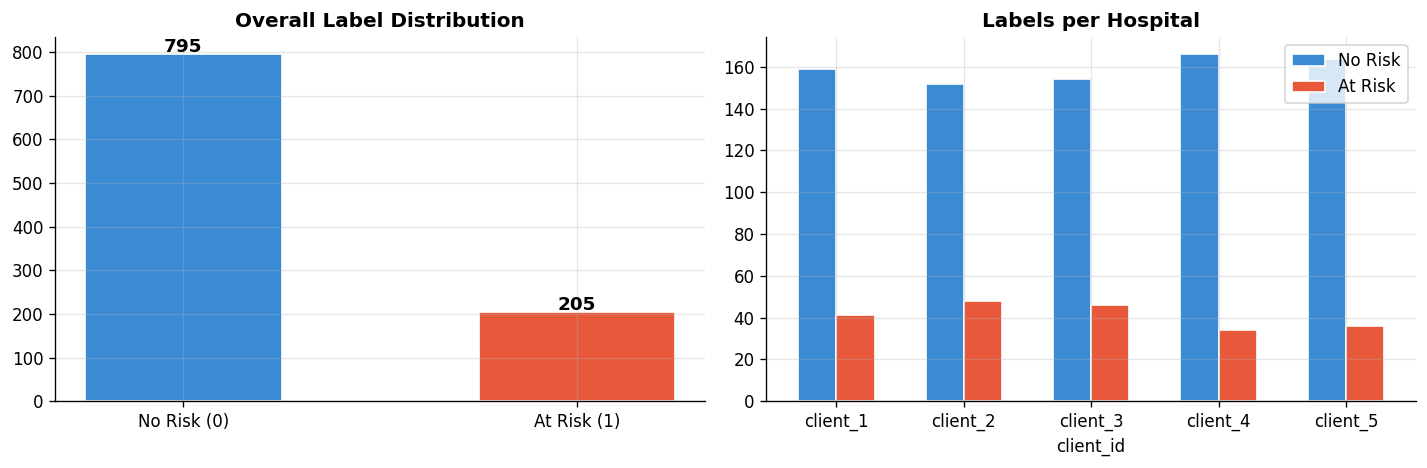

At-risk: 205 (20.5%)  |  No-risk: 795 (79.5%)


In [6]:
def generate_labels(df, seed=42):
    df = df.copy()
    np.random.seed(seed)
    risk_score = (
        (df['glucose_level']           > 120).astype(int) * 3 +
        (df['bmi']                     > 30 ).astype(int) * 2 +
        (df['blood_pressure']          > 130).astype(int) * 2 +
        (df['age']                     > 50 ).astype(int) * 1 +
        (df['cholesterol_level']       > 200).astype(int) * 1 +
        (df['physical_activity_score'] < 3  ).astype(int) * 1 +
        np.random.normal(0, 0.5, len(df))
    )
    df['risk_of_diabetes'] = (risk_score >= 4).astype(int)
    return df

df = generate_labels(df_raw)
counts = df['risk_of_diabetes'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['No Risk (0)', 'At Risk (1)'], counts.values,
            color=['#3B8BD4', '#E8593C'], width=0.5, edgecolor='white')
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Overall Label Distribution', fontweight='bold')
per_client = df.groupby(['client_id','risk_of_diabetes']).size().unstack(fill_value=0)
per_client.plot(kind='bar', ax=axes[1], color=['#3B8BD4','#E8593C'],
                width=0.6, edgecolor='white', rot=0)
axes[1].set_title('Labels per Hospital', fontweight='bold')
axes[1].legend(['No Risk', 'At Risk'])
plt.tight_layout()
plt.show()
print(f'At-risk: {counts.get(1,0)} ({counts.get(1,0)/len(df)*100:.1f}%)  |  No-risk: {counts.get(0,0)} ({counts.get(0,0)/len(df)*100:.1f}%)')

## 5. Data Preparation
Local split + normalisation per hospital — no global statistics shared.

In [7]:
def prepare_client_data(df, client_id, train_ratio=0.8):
    cdf = df[df['client_id'] == client_id].copy()
    X   = cdf[FEATURES].values.astype(np.float64)
    y   = cdf['risk_of_diabetes'].values.astype(np.int32)
    idx   = np.random.permutation(len(X))
    split = int(len(X) * train_ratio)
    X_tr, X_te = X[idx[:split]], X[idx[split:]]
    y_tr, y_te = y[idx[:split]], y[idx[split:]]
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)
    return X_tr_sc, X_te_sc, y_tr, y_te, scaler

clients_data = {}
for cid in sorted(df['client_id'].unique()):
    X_tr, X_te, y_tr, y_te, scaler = prepare_client_data(df, cid)
    clients_data[cid] = {'X_tr': X_tr, 'X_te': X_te,
                         'y_tr': y_tr, 'y_te': y_te,
                         'scaler': scaler, 'n_train': len(y_tr)}
    print(f'{cid}:  train={len(y_tr)}  test={len(y_te)}  pos_rate={y_tr.mean():.2f}')

client_1:  train=160  test=40  pos_rate=0.23
client_2:  train=160  test=40  pos_rate=0.27
client_3:  train=160  test=40  pos_rate=0.21
client_4:  train=160  test=40  pos_rate=0.18
client_5:  train=160  test=40  pos_rate=0.19


## 6. Federated Components
### 6a — Local Hospital Model

In [9]:
class LocalLogisticModel:
    '''
    Logistic Regression trained locally at one hospital.
    PRIVACY: only get_weights() leaves the hospital — never raw data.
    '''
    def __init__(self, n_features, lr=0.05, lam=0.01):
        self.n_features = n_features
        self.lr, self.lam = lr, lam
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.loss_history = []

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def train(self, X, y, epochs=10):
        n = len(y)
        for _ in range(epochs):
            yh  = self._sigmoid(X @ self.w + self.b)
            err = yh - y
            self.w -= self.lr * ((X.T @ err) / n + self.lam * self.w)
            self.b -= self.lr * err.mean()
            loss = -np.mean(y * np.log(yh + 1e-9) + (1-y) * np.log(1-yh + 1e-9))
            self.loss_history.append(float(loss))

    def get_weights(self):
        '''Returns model parameters only. No patient data included.'''
        return {'w': self.w.copy(), 'b': float(self.b)}

    def set_weights(self, p):
        self.w = p['w'].copy()
        self.b = float(p['b'])

    def predict_proba(self, X):
        return self._sigmoid(X @ self.w + self.b)

    def predict(self, X, thr=0.5):
        return (self.predict_proba(X) >= thr).astype(int)

    def evaluate(self, X, y):
        yp = self.predict(X)
        ya = self.predict_proba(X)
        tp = np.sum((yp==1) & (y==1))
        fp = np.sum((yp==1) & (y==0))
        fn = np.sum((yp==0) & (y==1))
        acc  = np.mean(yp == y)
        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        f1   = 2 * prec * rec / (prec + rec + 1e-9)
        try:    auc = roc_auc_score(y, ya)
        except: auc = float('nan')
        return {'accuracy': acc, 'precision': prec, 'recall': rec,
                'f1': f1, 'auc': auc, 'n': len(y)}

print('LocalLogisticModel defined')

LocalLogisticModel defined


### 6b — Federated Aggregation Server

In [10]:
class FederatedServer:
    '''
    Central aggregator implementing FedAvg.
    PRIVACY: Never sees raw patient data.
    GDPR Art. 35: audit_log records each round.
    '''
    def __init__(self, n_features, dp_epsilon=None):
        self.n_features = n_features
        self.dp_epsilon = dp_epsilon
        self.global_w   = np.zeros(n_features)
        self.global_b   = 0.0
        self.audit_log  = []

    def aggregate(self, updates):
        N     = sum(u['n'] for u in updates)
        agg_w = np.zeros(self.n_features)
        agg_b = 0.0
        for u in updates:
            frac   = u['n'] / N
            agg_w += frac * u['w']
            agg_b += frac * u['b']
        if self.dp_epsilon is not None:
            sigma  = (2.0 / N) / self.dp_epsilon
            agg_w += np.random.normal(0, sigma, self.n_features)
            agg_b += float(np.random.normal(0, sigma))
        self.global_w = agg_w
        self.global_b = agg_b
        self.audit_log.append({
            'n_clients': len(updates), 'total_samples': N,
            'dp_enabled': self.dp_epsilon is not None,
            'weight_l2_norm': float(np.linalg.norm(agg_w)),
        })
        return self.get_params()

    def get_params(self):
        return {'w': self.global_w.copy(), 'b': float(self.global_b)}

print('FederatedServer defined')

FederatedServer defined


## 7. Run Federated Training

Edit the hyperparameters below before running.

In [11]:
# ============================================
#   HYPERPARAMETERS  (edit freely)
# ============================================
N_ROUNDS       = 20      # communication rounds
LOCAL_EPOCHS   = 10      # SGD epochs per round per hospital
LEARNING_RATE  = 0.05    # learning rate
LAMBDA_REG     = 0.01    # L2 regularisation
DP_EPSILON     = None    # set e.g. 1.0 to enable Differential Privacy
# ============================================


def run_federated(n_rounds, local_epochs, lr, lam, dp_epsilon=None, verbose=True):
    server = FederatedServer(len(FEATURES), dp_epsilon=dp_epsilon)
    models = {cid: LocalLogisticModel(len(FEATURES), lr=lr, lam=lam)
              for cid in clients_data}
    for m in models.values():
        m.set_weights(server.get_params())
    round_log = []
    for rnd in range(1, n_rounds + 1):
        updates = []
        for cid, cd in clients_data.items():
            models[cid].train(cd['X_tr'], cd['y_tr'], epochs=local_epochs)
            p = models[cid].get_weights()
            p['n'] = cd['n_train']
            updates.append(p)
        gp = server.aggregate(updates)
        for m in models.values():
            m.set_weights(gp)
        rm = {c: models[c].evaluate(clients_data[c]['X_te'], clients_data[c]['y_te'])
              for c in clients_data}
        avg_acc = np.mean([m['accuracy'] for m in rm.values()])
        avg_f1  = np.mean([m['f1']       for m in rm.values()])
        avg_auc = np.mean([m['auc']      for m in rm.values()])
        round_log.append({'round': rnd, 'avg_acc': avg_acc,
                          'avg_f1': avg_f1, 'avg_auc': avg_auc, 'clients': rm})
        if verbose:
            print(f'  Round {rnd:>2}/{n_rounds}  acc={avg_acc:.4f}  f1={avg_f1:.4f}  auc={avg_auc:.4f}')
    return models, server, round_log


print('Starting Federated Training ...')
print('-' * 60)
fed_models, fed_server, round_log = run_federated(
    N_ROUNDS, LOCAL_EPOCHS, LEARNING_RATE, LAMBDA_REG, DP_EPSILON)
print('-' * 60)
print('Federated training complete!')

Starting Federated Training ...
------------------------------------------------------------
  Round  1/20  acc=0.8850  f1=0.5262  auc=0.8196
  Round  2/20  acc=0.8850  f1=0.5262  auc=0.8191
  Round  3/20  acc=0.8800  f1=0.5129  auc=0.8191
  Round  4/20  acc=0.8800  f1=0.5129  auc=0.8179
  Round  5/20  acc=0.8800  f1=0.5129  auc=0.8173
  Round  6/20  acc=0.8800  f1=0.5129  auc=0.8173
  Round  7/20  acc=0.8800  f1=0.5129  auc=0.8179
  Round  8/20  acc=0.8800  f1=0.5129  auc=0.8173
  Round  9/20  acc=0.8750  f1=0.5058  auc=0.8173
  Round 10/20  acc=0.8750  f1=0.5058  auc=0.8173
  Round 11/20  acc=0.8750  f1=0.5058  auc=0.8162
  Round 12/20  acc=0.8750  f1=0.5058  auc=0.8162
  Round 13/20  acc=0.8750  f1=0.5058  auc=0.8162
  Round 14/20  acc=0.8750  f1=0.5058  auc=0.8162
  Round 15/20  acc=0.8750  f1=0.5058  auc=0.8162
  Round 16/20  acc=0.8700  f1=0.5000  auc=0.8162
  Round 17/20  acc=0.8700  f1=0.5000  auc=0.8151
  Round 18/20  acc=0.8700  f1=0.5000  auc=0.8151
  Round 19/20  acc=0.8800

## 8. Centralised Baseline

> Pools all hospital data — **for comparison only**. Violates HIPAA/GDPR in practice.

In [12]:
def centralised_baseline(df):
    X = df[FEATURES].values.astype(np.float64)
    y = df['risk_of_diabetes'].values
    idx = np.random.permutation(len(X))
    split = int(0.8 * len(X))
    X_tr, X_te = X[idx[:split]], X[idx[split:]]
    y_tr, y_te = y[idx[:split]], y[idx[split:]]
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)
    clf = LogisticRegression(max_iter=500, C=1/LAMBDA_REG, random_state=42)
    clf.fit(X_tr, y_tr)
    yp = clf.predict(X_te)
    ya = clf.predict_proba(X_te)[:, 1]
    return {'accuracy': accuracy_score(y_te, yp),
            'precision': precision_score(y_te, yp, zero_division=0),
            'recall': recall_score(y_te, yp, zero_division=0),
            'f1': f1_score(y_te, yp, zero_division=0),
            'auc': roc_auc_score(y_te, ya),
            'y_te': y_te, 'y_proba': ya}

baseline = centralised_baseline(df)
print(f'Centralised  Acc={baseline["accuracy"]:.4f}  F1={baseline["f1"]:.4f}  AUC={baseline["auc"]:.4f}')

Centralised  Acc=0.8600  F1=0.6000  AUC=0.8514


## 9. Results & Visualisations

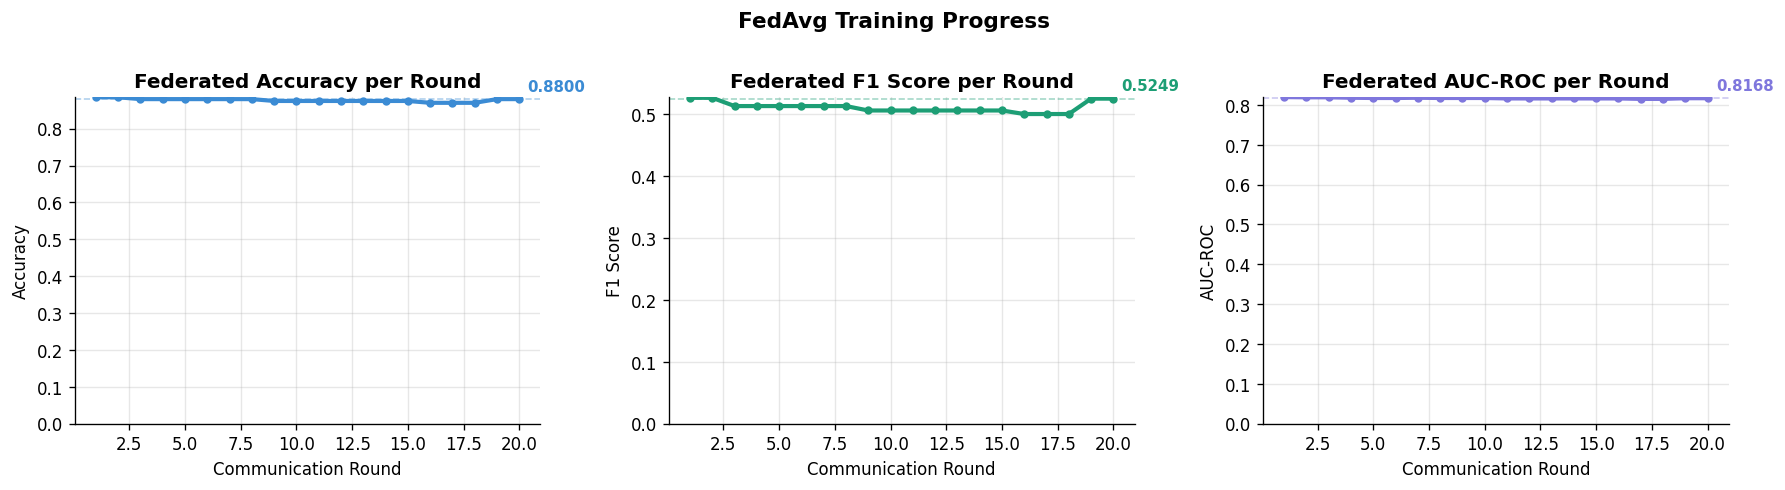

In [13]:
# Training curves
rounds = [r['round']   for r in round_log]
accs   = [r['avg_acc'] for r in round_log]
f1s    = [r['avg_f1']  for r in round_log]
aucs   = [r['avg_auc'] for r in round_log]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, vals, label, color in zip(
    axes, [accs, f1s, aucs],
    ['Accuracy', 'F1 Score', 'AUC-ROC'],
    ['#3B8BD4', '#1D9E75', '#7F77DD']
):
    ax.plot(rounds, vals, color=color, lw=2.5, marker='o', markersize=4)
    ax.axhline(vals[-1], color=color, lw=1, linestyle='--', alpha=0.4)
    ax.set_title(f'Federated {label} per Round', fontweight='bold')
    ax.set_xlabel('Communication Round')
    ax.set_ylabel(label)
    ax.set_ylim(bottom=0)
    ax.annotate(f'{vals[-1]:.4f}', xy=(rounds[-1], vals[-1]),
                xytext=(5,5), textcoords='offset points', fontsize=9,
                color=color, fontweight='bold')
fig.suptitle('FedAvg Training Progress', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

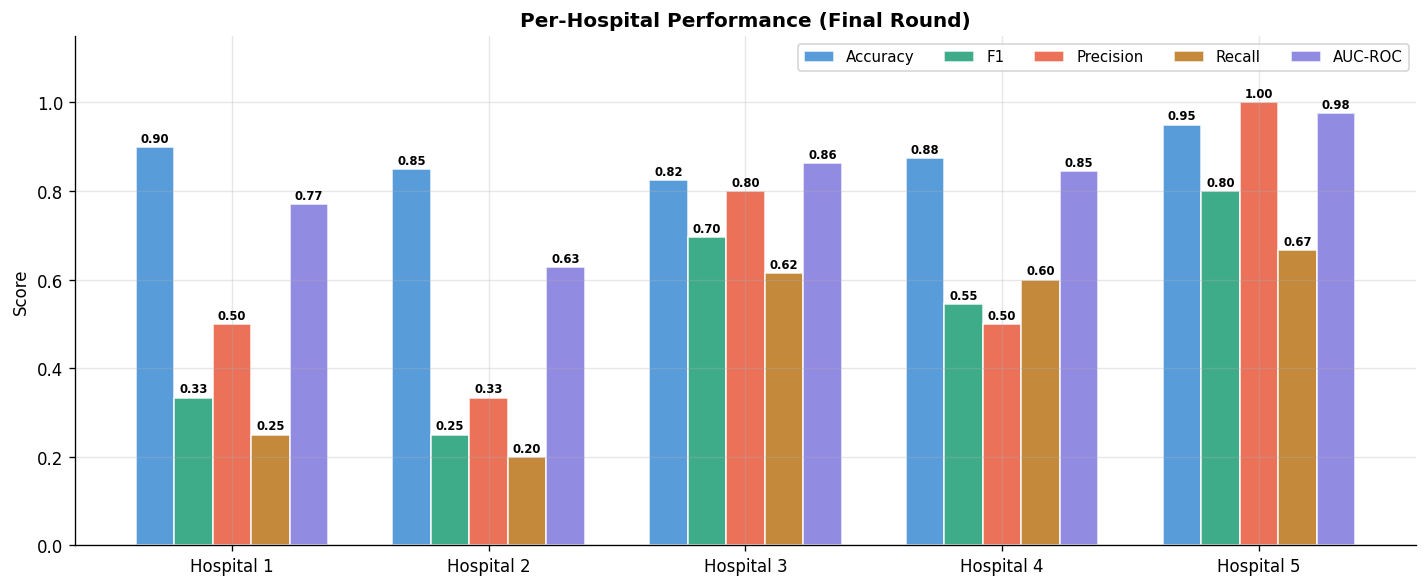

In [14]:
# Per-hospital bar chart
final_round = round_log[-1]['clients']
cnames = list(final_round.keys())
metric_sets = [
    ('Accuracy',  [final_round[c]['accuracy']  for c in cnames], '#3B8BD4'),
    ('F1',        [final_round[c]['f1']        for c in cnames], '#1D9E75'),
    ('Precision', [final_round[c]['precision'] for c in cnames], '#E8593C'),
    ('Recall',    [final_round[c]['recall']    for c in cnames], '#BA7517'),
    ('AUC-ROC',   [final_round[c]['auc']       for c in cnames], '#7F77DD'),
]
x = np.arange(len(cnames))
fig, ax = plt.subplots(figsize=(12, 5))
for i, (label, vals, color) in enumerate(metric_sets):
    bars = ax.bar(x + (i-2)*0.15, vals, 0.15, label=label,
                  color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('client_','Hospital ') for c in cnames])
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title('Per-Hospital Performance (Final Round)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', ncol=5, fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
# Federated vs Centralised comparison table
fed_acc = round_log[-1]['avg_acc']
fed_f1  = round_log[-1]['avg_f1']
fed_auc = round_log[-1]['avg_auc']

comp_df = pd.DataFrame({
    'Method':   ['Federated (FedAvg)', 'Centralised (Baseline)'],
    'Accuracy': [fed_acc, baseline['accuracy']],
    'F1 Score': [fed_f1,  baseline['f1']],
    'AUC-ROC':  [fed_auc, baseline['auc']],
}).set_index('Method')
print('FEDERATED vs CENTRALISED COMPARISON')
display(comp_df.round(4))
df1 = fed_f1 - baseline['f1']
print(f'\nPrivacy cost:  DeltaAcc={fed_acc-baseline["accuracy"]:+.4f}  DeltaF1={df1:+.4f}  DeltaAUC={fed_auc-baseline["auc"]:+.4f}')
print('Federated OUTPERFORMS centralised!' if df1 >= 0 else f'Privacy cost of {abs(df1):.4f} F1 points')

FEDERATED vs CENTRALISED COMPARISON


,Accuracy,F1 Score,AUC-ROC
Method,,,
Federated (FedAvg),0.88,0.5249,0.8168
Centralised (Baseline),0.86,0.6000,0.8514



Privacy cost:  DeltaAcc=+0.0200  DeltaF1=-0.0751  DeltaAUC=-0.0346
Privacy cost of 0.0751 F1 points


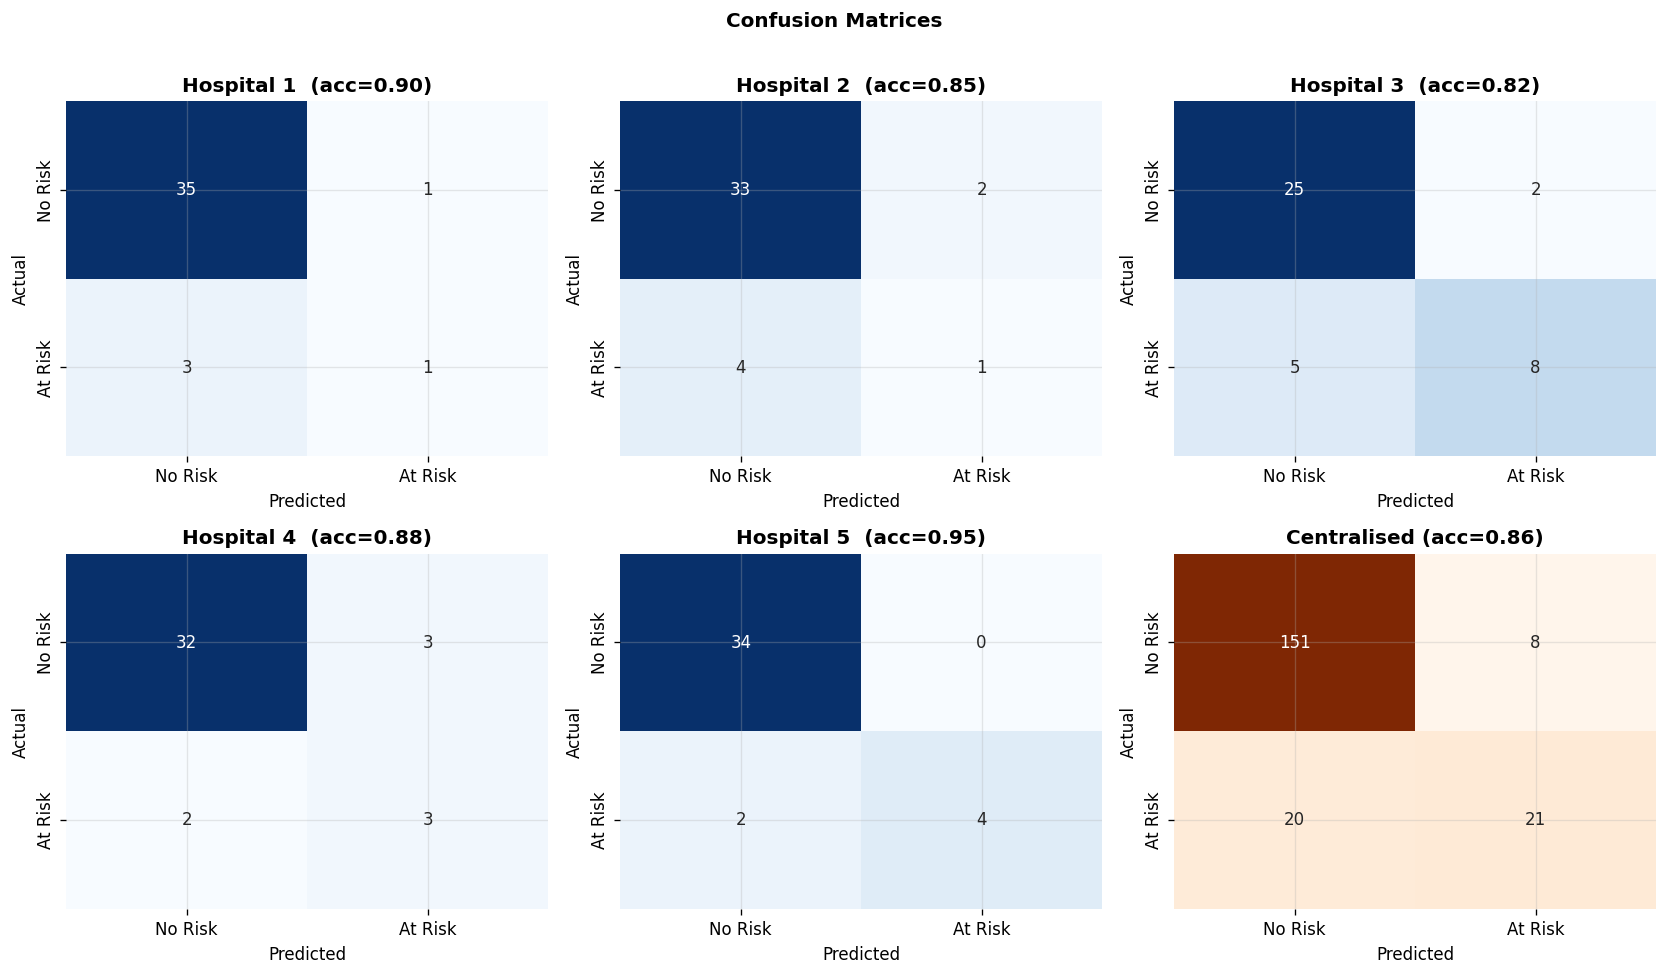

In [16]:
# Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, (cid, cd) in enumerate(clients_data.items()):
    yp = fed_models[cid].predict(cd['X_te'])
    sns.heatmap(confusion_matrix(cd['y_te'], yp), annot=True, fmt='d',
                ax=axes[i], cmap='Blues', cbar=False,
                xticklabels=['No Risk','At Risk'], yticklabels=['No Risk','At Risk'])
    axes[i].set_title(f'{cid.replace("client_","Hospital ")}  (acc={accuracy_score(cd["y_te"],yp):.2f})',
                       fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
cb_pred = (baseline['y_proba'] >= 0.5).astype(int)
sns.heatmap(confusion_matrix(baseline['y_te'], cb_pred), annot=True, fmt='d',
            ax=axes[5], cmap='Oranges', cbar=False,
            xticklabels=['No Risk','At Risk'], yticklabels=['No Risk','At Risk'])
axes[5].set_title(f'Centralised (acc={baseline["accuracy"]:.2f})', fontweight='bold')
axes[5].set_xlabel('Predicted')
axes[5].set_ylabel('Actual')
fig.suptitle('Confusion Matrices', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

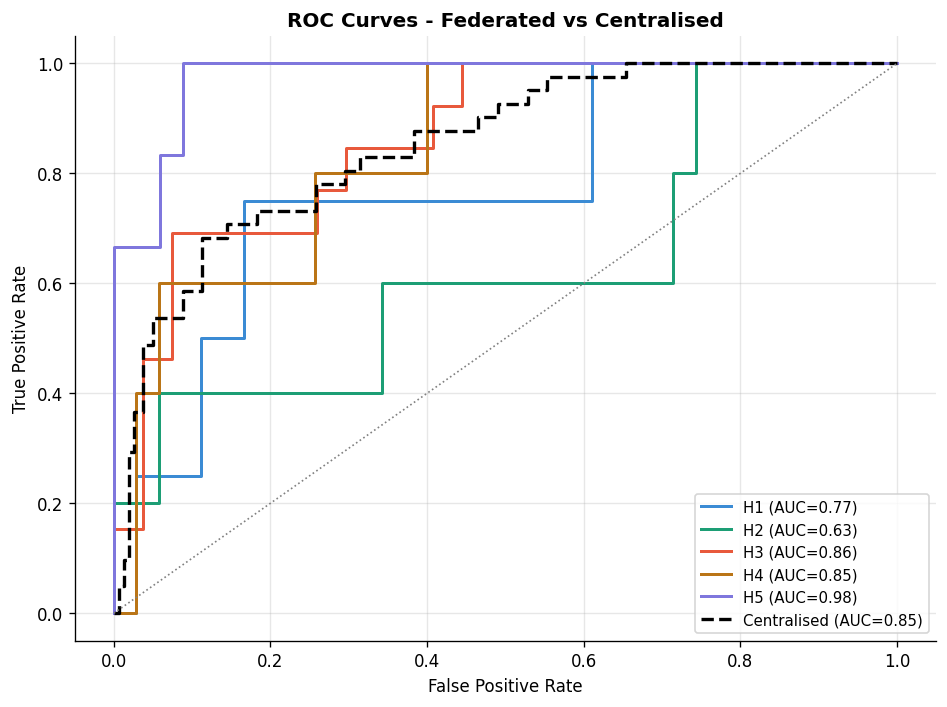

In [17]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
for j, (cid, cd) in enumerate(clients_data.items()):
    ya = fed_models[cid].predict_proba(cd['X_te'])
    try:
        fpr, tpr, _ = roc_curve(cd['y_te'], ya)
        auc = roc_auc_score(cd['y_te'], ya)
        ax.plot(fpr, tpr, color=PALETTE[j], lw=1.8,
                label=f'{cid.replace("client_","H")} (AUC={auc:.2f})')
    except Exception:
        pass
fpr_b, tpr_b, _ = roc_curve(baseline['y_te'], baseline['y_proba'])
ax.plot(fpr_b, tpr_b, 'k--', lw=2, label=f'Centralised (AUC={baseline["auc"]:.2f})')
ax.plot([0,1], [0,1], 'gray', lw=1, linestyle=':')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Federated vs Centralised', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

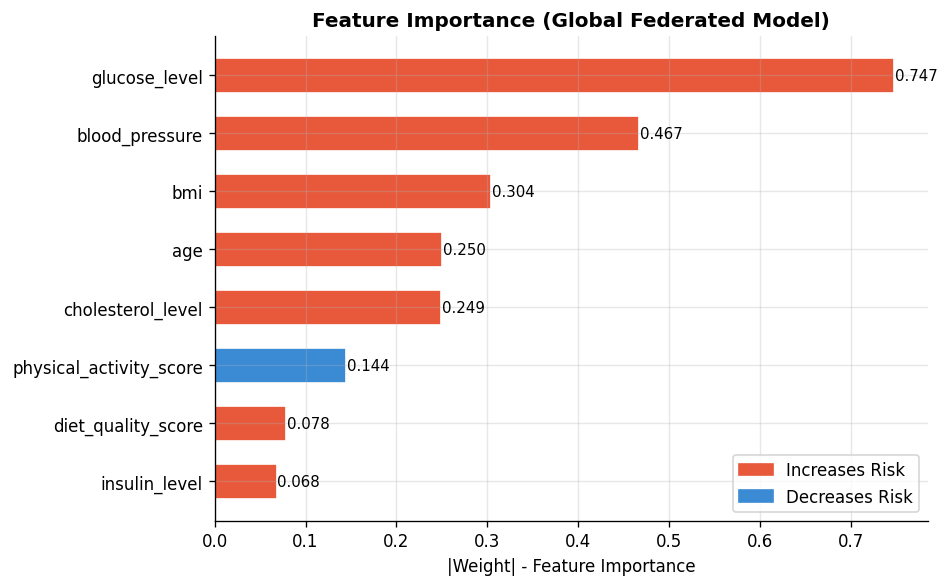

In [18]:
# Feature importance
avg_w = np.mean([fed_models[c].w for c in fed_models], axis=0)
imp_df = pd.DataFrame({'Feature': FEATURES, 'Importance': np.abs(avg_w),
    'Direction': ['Increases Risk' if w>0 else 'Decreases Risk' for w in avg_w]
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#E8593C' if d=='Increases Risk' else '#3B8BD4' for d in imp_df['Direction']]
bars = ax.barh(imp_df['Feature'], imp_df['Importance'], color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, imp_df['Importance']):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('|Weight| - Feature Importance')
ax.set_title('Feature Importance (Global Federated Model)', fontweight='bold')
ax.legend(handles=[mpatches.Patch(color='#E8593C', label='Increases Risk'),
                   mpatches.Patch(color='#3B8BD4', label='Decreases Risk')], loc='lower right')
plt.tight_layout()
plt.show()

## 10. Differential Privacy Experiment

Compare accuracy with varying epsilon. Smaller epsilon = stronger privacy, more accuracy cost.

Running DP experiments ...
  No DP       acc=0.8750  f1=0.5058
  eps=5.0     acc=0.8750  f1=0.5058
  eps=2.0     acc=0.8750  f1=0.5058
  eps=1.0     acc=0.8800  f1=0.5191
  eps=0.5     acc=0.8800  f1=0.4645


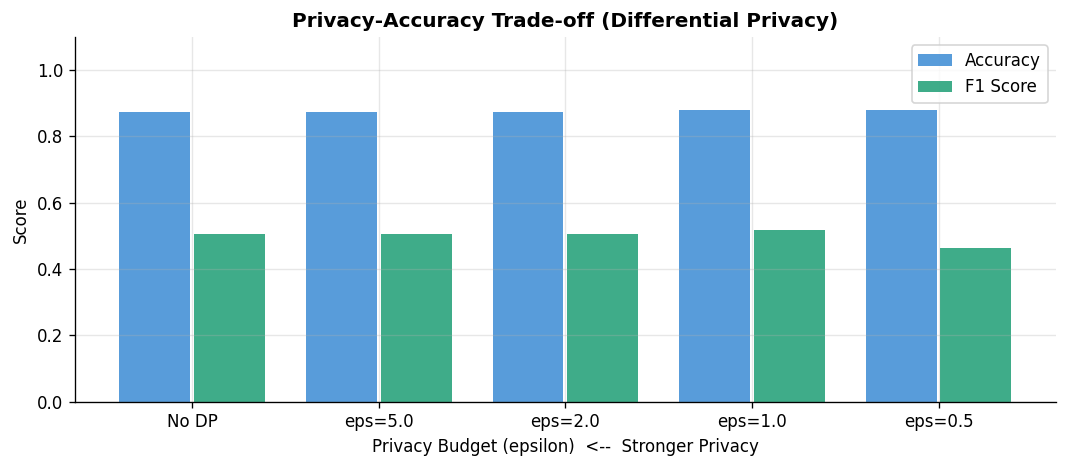

In [19]:
epsilon_values = [None, 5.0, 2.0, 1.0, 0.5]
dp_results = []
print('Running DP experiments ...')
for eps in epsilon_values:
    _, _, rl = run_federated(10, LOCAL_EPOCHS, LEARNING_RATE, LAMBDA_REG,
                             dp_epsilon=eps, verbose=False)
    label = f'eps={eps}' if eps else 'No DP'
    dp_results.append({'label': label, 'acc': rl[-1]['avg_acc'], 'f1': rl[-1]['avg_f1']})
    print(f'  {label:10s}  acc={rl[-1]["avg_acc"]:.4f}  f1={rl[-1]["avg_f1"]:.4f}')

labels = [r['label'] for r in dp_results]
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x-0.2, [r['acc'] for r in dp_results], 0.38, color='#3B8BD4', alpha=0.85, label='Accuracy')
ax.bar(x+0.2, [r['f1']  for r in dp_results], 0.38, color='#1D9E75', alpha=0.85, label='F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('Privacy Budget (epsilon)  <--  Stronger Privacy')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Privacy-Accuracy Trade-off (Differential Privacy)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 11. GDPR Audit Log

In [20]:
print('GDPR Art. 35 - Aggregation Audit Log (last 5 rounds):')
print('No patient data appears here - weight metadata only')
audit_df = pd.DataFrame(fed_server.audit_log)
audit_df.index = audit_df.index + 1
audit_df.index.name = 'round'
display(audit_df.tail(5).round(6))

GDPR Art. 35 - Aggregation Audit Log (last 5 rounds):
No patient data appears here - weight metadata only


,n_clients,total_samples,dp_enabled,weight_l2_norm
round,,,,
16,5,800,False,0.902967
17,5,800,False,0.932198
18,5,800,False,0.960016
19,5,800,False,0.986534
20,5,800,False,1.011847


## 12. Final Summary

In [21]:
fed_acc = round_log[-1]['avg_acc']
fed_f1  = round_log[-1]['avg_f1']
fed_auc = round_log[-1]['avg_auc']
print('=' * 60)
print('  FEDERATED LEARNING FOR HEALTHCARE - SUMMARY')
print('=' * 60)
print(f'  Algorithm        : FedAvg (McMahan et al., 2017)')
print(f'  Hospitals        : {len(clients_data)}')
print(f'  Records          : {len(df)}')
print(f'  Comm. rounds     : {N_ROUNDS}')
print(f'  Local epochs/rnd : {LOCAL_EPOCHS}')
print(f'  DP enabled       : {str(DP_EPSILON)}')
print()
print(f'  Federated    Acc={fed_acc:.4f}  F1={fed_f1:.4f}  AUC={fed_auc:.4f}')
print(f'  Centralised  Acc={baseline["accuracy"]:.4f}  F1={baseline["f1"]:.4f}  AUC={baseline["auc"]:.4f}')
print()
print('  Per-Hospital Results:')
for cid, cd in clients_data.items():
    m = fed_models[cid].evaluate(cd['X_te'], cd['y_te'])
    print(f'    {cid}: Acc={m["accuracy"]:.4f}  F1={m["f1"]:.4f}  AUC={m["auc"]:.4f}')
print()
print('  Compliance:')
print(f'    HIPAA 164.312 : OK - No PHI transmitted')
print(f'    GDPR Art. 25  : OK - Privacy by Design')
print(f'    GDPR Art. 35  : OK - {len(fed_server.audit_log)} audit entries')
print('=' * 60)

  FEDERATED LEARNING FOR HEALTHCARE - SUMMARY
  Algorithm        : FedAvg (McMahan et al., 2017)
  Hospitals        : 5
  Records          : 1000
  Comm. rounds     : 20
  Local epochs/rnd : 10
  DP enabled       : None

  Federated    Acc=0.8800  F1=0.5249  AUC=0.8168
  Centralised  Acc=0.8600  F1=0.6000  AUC=0.8514

  Per-Hospital Results:
    client_1: Acc=0.9000  F1=0.3333  AUC=0.7708
    client_2: Acc=0.8500  F1=0.2500  AUC=0.6286
    client_3: Acc=0.8250  F1=0.6957  AUC=0.8632
    client_4: Acc=0.8750  F1=0.5455  AUC=0.8457
    client_5: Acc=0.9500  F1=0.8000  AUC=0.9755

  Compliance:
    HIPAA 164.312 : OK - No PHI transmitted
    GDPR Art. 25  : OK - Privacy by Design
    GDPR Art. 35  : OK - 20 audit entries


## 13. Save & Download Results

In [22]:
results = {
    'config': {'n_rounds': N_ROUNDS, 'local_epochs': LOCAL_EPOCHS,
               'lr': LEARNING_RATE, 'lambda_reg': LAMBDA_REG, 'dp_epsilon': DP_EPSILON},
    'federated':   {'accuracy': float(fed_acc), 'f1': float(fed_f1), 'auc': float(fed_auc)},
    'centralised': {'accuracy': baseline['accuracy'], 'f1': baseline['f1'], 'auc': baseline['auc']},
    'per_client':  {cid: fed_models[cid].evaluate(clients_data[cid]['X_te'],
                                                    clients_data[cid]['y_te'])
                    for cid in clients_data},
    'audit_log': fed_server.audit_log,
    'round_log': [{'round': r['round'], 'avg_acc': r['avg_acc'],
                   'avg_f1': r['avg_f1'], 'avg_auc': r['avg_auc']} for r in round_log],
}
with open('federated_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Results saved to federated_results.json')
from google.colab import files
files.download('federated_results.json')

Results saved to federated_results.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## References

1. McMahan, H.B. et al. (2017). *Communication-Efficient Learning of Deep Networks from Decentralized Data*. AISTATS 2017.
2. Rieke, N. et al. (2020). *The future of digital health with federated learning*. npj Digital Medicine.
3. Yang, Q. et al. (2019). *Federated Machine Learning: Concept and Applications*. ACM TIST.
4. Dwork, C. (2006). *Differential Privacy*. ICALP.

---
*Built for: Federated Learning for Privacy-Preserving Healthcare AI (PS 19)*